# 01. 부도 예측 모델 - 탐색적 데이터 분석 (EDA)

**목적**: 부도 예측 모델 개발을 위한 데이터 탐색 및 이해

**주요 분석 내용**:
1. 데이터 로드 및 기본 통계
2. 부도율 분석 (클래스 불균형 확인)
3. 피처 분포 분석
4. 결측치 패턴 분석
5. 상관관계 분석
6. 부도 기업 vs 정상 기업 비교

**데이터 소스**: PostgreSQL DWH (클렌징 완료된 데이터)

## 1. 환경 설정

In [1]:
# 기본 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings

# 데이터베이스 연결
from sqlalchemy import create_engine
import sys
sys.path.append('/Users/kje/coding/project/fintech-cb-pipeline')
from shared.config_loader import DB_URL, config

# 시각화 설정
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'AppleGothic'  # macOS 한글 폰트
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
sns.set_style('whitegrid')

# pandas 출력 옵션
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✓ 환경 설정 완료")

✓ 환경 설정 완료


## 2. 데이터 로드

**데이터 구조**:
- `dwh.dim_company`: 기업 차원 (업종, 종업원 수 등)
- `dwh.fact_financial_statement`: 재무제표 사실 (자산, 부채, 자본)
- `dwh.fact_financial_ratios`: 재무비율 사실 (부채비율, ROE 등)
- `dwh.fact_credit_behavior`: 신용행동 사실 (부도여부, 신용등급, 연체정보)

**샘플링**: 전체 60만 행 중 10만 행 샘플 (EDA용)

In [ ]:
# Parquet 파일에서 데이터 로드
data_path = '../data/raw_data_20210801.parquet'

print("데이터 로딩 중... (기준년월: 2021-08)")
df = pd.read_parquet(data_path)
print(f"✓ 데이터 로드 완료: {len(df):,}행 × {len(df.columns)}열")
print(f"✓ 기준년월: {df['base_date'].unique()}")

# 기본 정보
print("\n" + "="*60)
print(" 데이터 기본 정보")
print("="*60)
df.info()

In [10]:
# 데이터 미리보기
df.head(10)

NameError: name 'df' is not defined

## 3. 타겟 변수 분석 - 부도율

**클래스 불균형 확인**: 부도 기업은 전체의 ~1.5%로 예상

In [11]:
# 부도율 계산
default_counts = df['default_yn'].value_counts()
default_rate = df['default_yn'].mean() * 100

print("="*60)
print(" 부도 현황")
print("="*60)
print(f"정상 기업: {default_counts.get(0, 0):,}개 ({(1-default_rate/100)*100:.2f}%)")
print(f"부도 기업: {default_counts.get(1, 0):,}개 ({default_rate:.2f}%)")
print(f"\n클래스 불균형 비율: 1:{int(default_counts.get(0, 0) / default_counts.get(1, 1))}")
print("="*60)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 막대 그래프
default_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('부도 기업 수', fontsize=14, fontweight='bold')
axes[0].set_xlabel('부도 여부 (0=정상, 1=부도)')
axes[0].set_ylabel('기업 수')
axes[0].set_xticklabels(['정상', '부도'], rotation=0)

# 파이 차트
axes[1].pie(default_counts, labels=['정상', '부도'], autopct='%1.2f%%', 
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('부도 비율', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n⚠️  클래스 불균형이 심각함 → SMOTE 또는 scale_pos_weight 필요")

NameError: name 'df' is not defined

## 4. 기본 통계 분석

In [12]:
# 수치형 컬럼만 선택
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('company_sk')  # 식별자 제외

# 기술 통계
df[numeric_cols].describe().T

NameError: name 'df' is not defined

## 5. 결측치 분석

재무비율 일부는 높은 결측률 예상 (분모가 0이거나 음수인 경우)

In [13]:
# 결측치 비율 계산
missing_stats = pd.DataFrame({
    '결측수': df.isnull().sum(),
    '결측률(%)': df.isnull().sum() / len(df) * 100
}).sort_values('결측률(%)', ascending=False)

# 결측률 10% 이상인 컬럼만 출력
high_missing = missing_stats[missing_stats['결측률(%)'] >= 10]

if len(high_missing) > 0:
    print("="*60)
    print(" 결측률 10% 이상 컬럼")
    print("="*60)
    print(high_missing)
    print("="*60)
else:
    print("✓ 결측률 10% 이상인 컬럼 없음")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# missingno 매트릭스
msno.matrix(df[numeric_cols[:30]], ax=axes[0], sparkline=False)
axes[0].set_title('결측치 패턴 (첫 30개 컬럼)', fontsize=12, fontweight='bold')

# 결측률 상위 20개 컬럼 막대 그래프
top_missing = missing_stats.head(20)
if len(top_missing) > 0:
    top_missing['결측률(%)'].plot(kind='barh', ax=axes[1], color='coral')
    axes[1].set_title('결측률 Top 20 컬럼', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('결측률 (%)')

plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

## 6. 피처 분포 분석

### 6.1 재무제표 Raw 데이터 (로그 스케일)

NameError: name 'df' is not defined

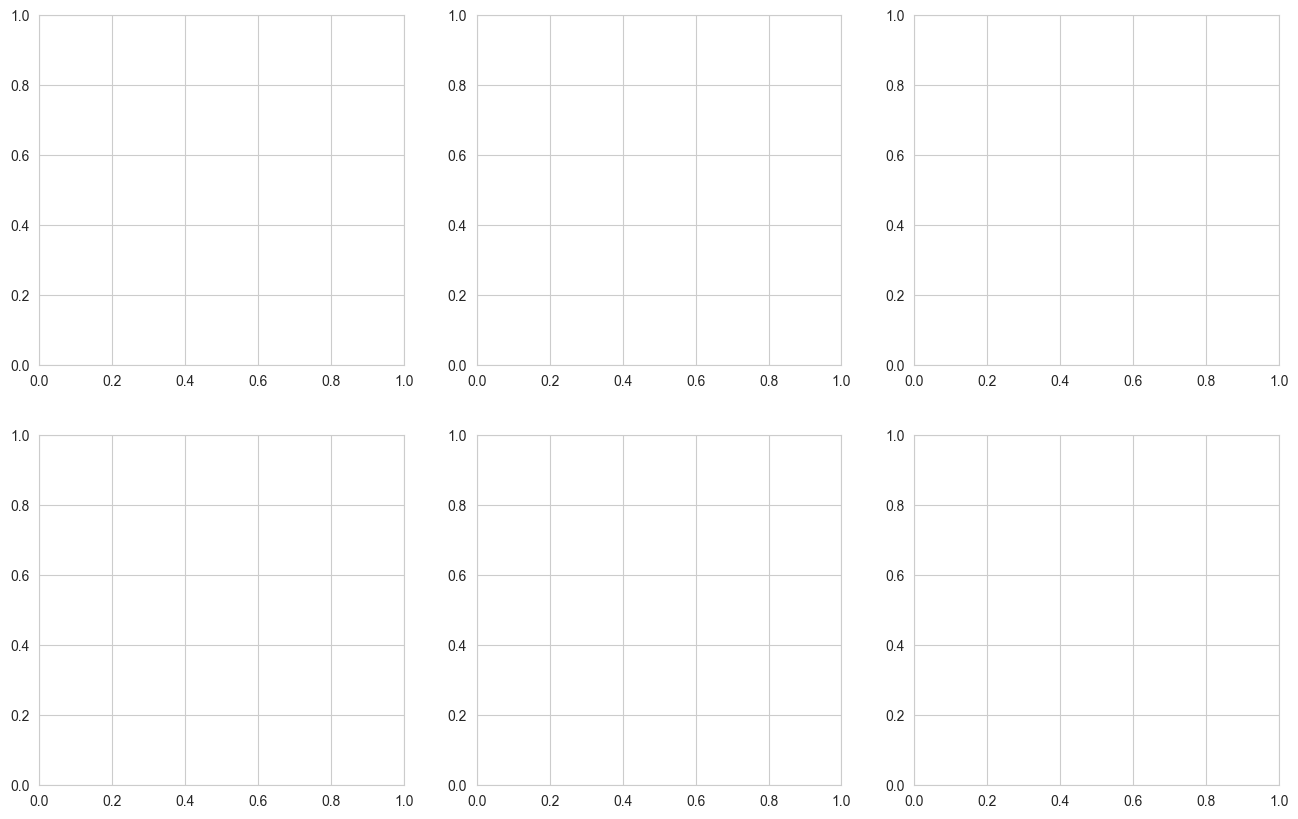

In [14]:
# 주요 재무 지표 (Raw)
financial_raw = ['total_asset', 'total_equity', 'total_debt', 'revenue', 'net_income', 'operating_cashflow']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(financial_raw):
    if col in df.columns:
        # 양수 값만 필터링 (로그 변환을 위해)
        positive_values = df[df[col] > 0][col]
        
        axes[i].hist(np.log10(positive_values), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
        axes[i].set_title(f'{col} (log10 scale)', fontsize=11, fontweight='bold')
        axes[i].set_xlabel('log10(금액)')
        axes[i].set_ylabel('빈도')
        axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Raw 재무 데이터는 로그 변환 후 사용 권장 (스케일 차이 큼)")

### 6.2 재무비율 분포

In [ ]:
# 주요 재무비율
key_ratios = ['debt_ratio', 'equity_ratio', 'current_ratio', 'quick_ratio', 
              'operating_margin', 'net_margin', 'roe', 'roa']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_ratios):
    if col in df.columns:
        # 이상치 제거한 분포 (IQR)
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        filtered = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)][col]
        
        axes[i].hist(filtered, bins=50, color='mediumseagreen', alpha=0.7, edgecolor='black')
        axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
        axes[i].set_xlabel('비율')
        axes[i].set_ylabel('빈도')
        axes[i].axvline(filtered.median(), color='red', linestyle='--', label=f'중위값: {filtered.median():.2f}')
        axes[i].legend(fontsize=8)
        axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 6.3 신용행동 피처 분포

In [ ]:
# 신용등급 분포
if 'credit_grade' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 전체 신용등급 분포
    df['credit_grade'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
    axes[0].set_title('신용등급 분포 (전체)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('신용등급 (1=최우수, 10=최하)')
    axes[0].set_ylabel('기업 수')
    axes[0].grid(alpha=0.3)
    
    # 부도 여부별 신용등급 분포
    df.groupby(['credit_grade', 'default_yn']).size().unstack().plot(kind='bar', ax=axes[1], stacked=False, 
                                                                      color=['#2ecc71', '#e74c3c'])
    axes[1].set_title('신용등급별 부도 여부', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('신용등급')
    axes[1].set_ylabel('기업 수')
    axes[1].legend(['정상', '부도'])
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 공공신용정보 (D2B)
credit_events = ['public_credit_event_1', 'public_credit_event_2']
for col in credit_events:
    if col in df.columns:
        print(f"\n{col} 분포:")
        print(df[col].value_counts().sort_index())
        print(f"결측률: {df[col].isnull().sum() / len(df) * 100:.2f}%")

## 7. 상관관계 분석

In [ ]:
# 타겟 변수(default_yn)와의 상관관계
correlation_with_target = df[numeric_cols].corrwith(df['default_yn']).sort_values(ascending=False)

print("="*60)
print(" 부도 여부와 상관관계 높은 피처 Top 20")
print("="*60)
print(correlation_with_target.head(20))
print("\n")
print("="*60)
print(" 부도 여부와 음의 상관관계 높은 피처 Top 20")
print("="*60)
print(correlation_with_target.tail(20))
print("="*60)

# 시각화
fig, ax = plt.subplots(figsize=(10, 12))
correlation_with_target.plot(kind='barh', ax=ax, color=correlation_with_target.apply(lambda x: '#e74c3c' if x > 0 else '#3498db'))
ax.set_title('피처와 부도 여부 간 상관계수', fontsize=14, fontweight='bold')
ax.set_xlabel('상관계수')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 주요 재무비율 간 상관관계 히트맵
selected_features = ['debt_ratio', 'current_ratio', 'operating_margin', 'net_margin', 
                     'roe', 'roa', 'revenue_growth', 'net_income_growth', 'default_yn']

# 존재하는 컬럼만 선택
selected_features = [col for col in selected_features if col in df.columns]

if len(selected_features) > 0:
    corr_matrix = df[selected_features].corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('주요 재무비율 상관관계 히트맵', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 8. 부도 기업 vs 정상 기업 비교

In [ ]:
# 부도 여부별 통계 비교
comparison_features = ['debt_ratio', 'current_ratio', 'operating_margin', 'net_margin', 
                       'roe', 'roa', 'total_asset', 'revenue']

# 존재하는 컬럼만 선택
comparison_features = [col for col in comparison_features if col in df.columns]

comparison_stats = df.groupby('default_yn')[comparison_features].agg(['mean', 'median', 'std']).T
comparison_stats.columns = ['정상_평균', '정상_중위', '정상_표준편차', '부도_평균', '부도_중위', '부도_표준편차']

print("="*80)
print(" 부도 기업 vs 정상 기업 재무지표 비교")
print("="*80)
print(comparison_stats)
print("="*80)

In [ ]:
# 박스플롯으로 비교
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(comparison_features[:8]):
    if col in df.columns:
        # 이상치 제거
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        filtered_df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]
        
        filtered_df.boxplot(column=col, by='default_yn', ax=axes[i])
        axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
        axes[i].set_xlabel('부도 여부 (0=정상, 1=부도)')
        axes[i].set_ylabel('값')
        axes[i].get_figure().suptitle('')  # 전체 제목 제거

plt.tight_layout()
plt.show()

## 9. 업종별 부도율 분석

In [ ]:
# 업종별 부도율
if 'industry_code' in df.columns:
    industry_default = df.groupby('industry_code').agg({
        'default_yn': ['count', 'sum', 'mean']
    })
    industry_default.columns = ['총_기업수', '부도_기업수', '부도율']
    industry_default['부도율'] = industry_default['부도율'] * 100
    industry_default = industry_default.sort_values('부도율', ascending=False)
    
    print("="*60)
    print(" 업종별 부도율 Top 20")
    print("="*60)
    print(industry_default.head(20))
    print("="*60)
    
    # 시각화
    fig, ax = plt.subplots(figsize=(12, 8))
    industry_default.head(20)['부도율'].plot(kind='barh', ax=ax, color='coral', edgecolor='black')
    ax.set_title('업종별 부도율 Top 20', fontsize=14, fontweight='bold')
    ax.set_xlabel('부도율 (%)')
    ax.set_ylabel('업종 코드')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 10. 요약 및 다음 단계

### 주요 발견사항
1. **클래스 불균형**: 부도율 ~1.5% → SMOTE 또는 scale_pos_weight 필요
2. **결측치**: 일부 재무비율에서 높은 결측률 확인 → 대체 전략 필요
3. **피처 스케일**: Raw 재무 데이터는 로그 변환 필수 (스케일 차이 큼)
4. **상관관계**: 특정 재무비율이 부도와 높은 상관관계 → 중요 피처 후보
5. **업종 효과**: 업종별 부도율 차이 존재 → 업종을 피처로 활용

### 다음 노트북: 02_feature_engineering.ipynb
- 피처 선택 (상관관계, 중요도 기반)
- 파생 피처 생성 (cash_to_debt, accrual_ratio 등)
- 결측치 처리 전략
- 피처 스케일링 (로그 변환, 표준화)
- 최종 피처 세트 구성 (30-40개)

In [ ]:
# 데이터 저장 (다음 노트북에서 사용)
df.to_pickle('../artifacts/01_eda_data.pkl')
print("✓ 데이터 저장 완료: ml/artifacts/01_eda_data.pkl")